In [1]:
import zipfile
import torch
import io
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision
import torch.nn as nn
from torchvision import transforms
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
import numpy as np
import os
from scipy.stats import pearsonr
from scipy.signal import butter, sosfiltfilt

In [2]:
os.listdir("/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg")

['Preprocessed_data', 'Image_set', 'Image_feature', 'Image_set_Resize']

In [3]:
def bandpass_filter(
    eeg: np.ndarray,
    lowcut: float = 0.1,
    highcut: float = 20.0,
    fs: float = 250,
    order: int = 5,
) -> np.ndarray:
    if eeg.ndim != 3:
        raise ValueError(f"Expected 3D array (batch, channels, time), got shape {eeg.shape}")

    nyquist = fs / 2.0
    if lowcut <= 0 or highcut >= nyquist:
        raise ValueError(
            f"Cutoff frequencies must satisfy 0 < lowcut < highcut < nyquist ({nyquist} Hz). "
            f"Got lowcut={lowcut}, highcut={highcut}."
        )

    sos = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band", output="sos")

    # Apply filter along time axis for all batch×channels at once
    return sosfiltfilt(sos, eeg, axis=-1)

In [4]:
file_path = "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-01/train.pt"

data = torch.load(file_path, map_location="cpu", weights_only=False)

print(type(data))

additional_subs = ["/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-02/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-03/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-04/train.pt"]
#additional_subs = []

for i in range(len(additional_subs)):
    print("Sub : ", i + 2)
    new_sub = torch.load(additional_subs[i], map_location="cpu", weights_only=False)
    for j in range (len(new_sub['img'])):
        if new_sub['img'][j] == data["img"][j]:
            data["eeg"][j] += new_sub["eeg"][j]
        else :
            print("Miss : ",new_sub['img'][j], data['img'][j])
            raise ValueError

print("Averaging participants...")
eeg = []

for i in range(len(data["eeg"])):

        data["eeg"][i] /= len(additional_subs) +1
        data["eeg"][i] = bandpass_filter(data["eeg"][i])
        if i%1000 ==0:
            print(i)

print("Finished !")
        

<class 'dict'>
Sub :  2
Sub :  3
Sub :  4
Averaging participants...
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Finished !


In [5]:
print(data["eeg"][0].shape) # First EEG record (time series)
print(data["img"][0]) # Image path associated to First EEG record

(1, 271, 201)
training_images/00001_aardvark/aardvark_01b.jpg


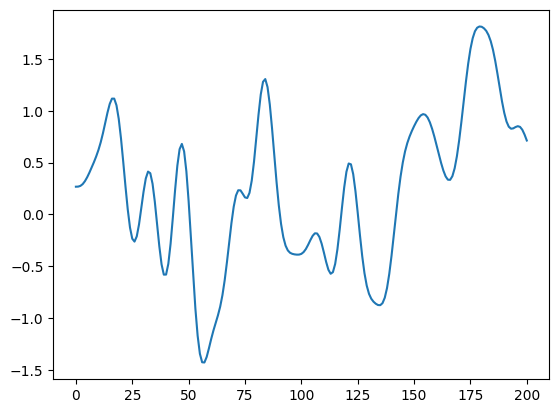

In [6]:
plt.plot(data["eeg"][0].squeeze()[0, :])
plt.show()

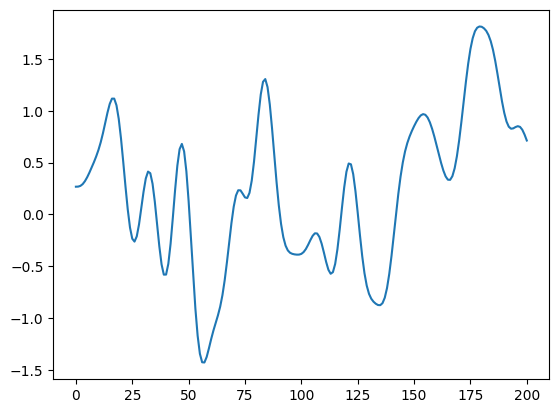

In [7]:
plt.plot(data["eeg"][0].squeeze()[0, :])
plt.show()

In [8]:
#Cell coded with the help of LLMs
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Authentication : uses kaggle secret to retrieve huggingface token, necessary for access to DINO
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login
login(token=hf_token)

In [9]:
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
model = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [10]:
output = model(torch.zeros(1,3, 800, 800), output_hidden_states = True) # Run a DINO forward pass on an empty tensor

In [11]:
print(output.last_hidden_state.shape) #Output without pooling
print(output.pooler_output.shape) #Output with pooling
hidden_states = output.hidden_states
for i, layer_output in enumerate(hidden_states):
    print(f"Layer {i}: {layer_output.shape}")

print(type(hidden_states))

torch.Size([1, 2505, 384])
torch.Size([1, 384])
Layer 0: torch.Size([1, 2505, 384])
Layer 1: torch.Size([1, 2505, 384])
Layer 2: torch.Size([1, 2505, 384])
Layer 3: torch.Size([1, 2505, 384])
Layer 4: torch.Size([1, 2505, 384])
Layer 5: torch.Size([1, 2505, 384])
Layer 6: torch.Size([1, 2505, 384])
Layer 7: torch.Size([1, 2505, 384])
Layer 8: torch.Size([1, 2505, 384])
Layer 9: torch.Size([1, 2505, 384])
Layer 10: torch.Size([1, 2505, 384])
Layer 11: torch.Size([1, 2505, 384])
Layer 12: torch.Size([1, 2505, 384])
<class 'tuple'>


In [56]:
base_path = "/kaggle/input/datasets/jibrilelhassani"
root_folder = "/things-meg/things-meg/Image_set/training_images/"
root_path = base_path + root_folder
model_type = "dino"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.eval()
model = model.to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

data_dict = data

image_to_eeg = {
    img_path: torch.tensor(eeg)
    for img_path, eeg in zip(data_dict["img"], data_dict["eeg"])
}

features = []
eeg_list = []
counter = 0
hidden_state_list = []
with torch.no_grad():

    for class_folder in os.listdir(root_path):

        class_path = root_path + class_folder


        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            

            full_path = class_path + "/" + file_name

            relative_path = "training_images/" + class_folder + "/" +  file_name
            if relative_path in image_to_eeg:

                img = Image.open(full_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)

                output = model(img_tensor, output_hidden_states = True)
                hidden_states = list(output.hidden_states)

                hidden_states = torch.stack(hidden_states)

                hidden_states = hidden_states.squeeze().mean(1)

                counter += 1
                    
                hidden_state_list.append(hidden_states)
                
                eeg_list.append(image_to_eeg[relative_path])


            if counter % 1000 == 0:
                print(f"Iteration {counter}")

        if counter > 20000:
            break


eeg_tensor = torch.stack(eeg_list, dim=0)

hidden_state_list = torch.stack(hidden_state_list)



cuda
Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000
Iteration 5000
Iteration 6000
Iteration 7000
Iteration 8000
Iteration 9000
Iteration 10000
Iteration 11000
Iteration 12000
Iteration 13000
Iteration 14000
Iteration 15000
Iteration 16000
Iteration 17000
Iteration 18000
Iteration 19000


In [60]:
print(eeg_tensor.shape)
print(hidden_state_list.shape)


torch.Size([19848, 271, 201])
torch.Size([19848, 13, 384])


In [22]:
print(hidden_state_list.shape)
print(eeg_tensor.shape)

torch.Size([19848, 13, 384])
torch.Size([19848, 1, 271, 201])


In [23]:
def train_ridge_model(features, eeg_tensor, verbose = True):
    features_train, features_test, eeg_tensor_train, eeg_tensor_test = train_test_split(features, eeg_tensor, test_size=0.15)
    clf = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1]).fit(features_train, eeg_tensor_train)
    
    preds_test = clf.predict(features_test)
    eeg_test_np = np.array(eeg_tensor_test)
    trivial_preds = np.tile(np.array(eeg_tensor_train).mean(0), (len(eeg_test_np), 1))
    if verbose :
        print(f"Train set error {((clf.predict(features_train) - np.array(eeg_tensor_train))**2).mean():4f}")
        print(f"Test set error {((preds_test - eeg_test_np)**2).mean():4f}")
        print(f"Trivial model test set error {((trivial_preds - eeg_test_np)**2).mean():4f}")

    correlations = [pearsonr(preds_test[:, i], eeg_test_np[:, i])[0] for i in range(eeg_test_np.shape[1])]
    if verbose :
        print(f"Test Pearson r (mean over channels): {np.mean(correlations):.4f}")
    
    return np.mean(correlations)

In [26]:
np.random.seed(24)
correlations = [[] for _ in range(13)]
hidden_state_list = hidden_state_list.cpu()
for layer in range(hidden_state_list.shape[1]):
    print(layer)
    for timestamp in range(0,eeg_tensor.shape[-1]):
    
        eeg_tensor_temp = eeg_tensor[:,:,:,timestamp].squeeze()
        correlation = train_ridge_model(hidden_state_list[:,layer,:], eeg_tensor_temp, verbose = False)
        correlations[layer].append(correlation)
        if timestamp % 100 == 0:
            print(timestamp)

0
0
100
200
1
0
100
200
2
0
100
200
3
0
100
200
4
0
100
200
5
0
100
200
6
0
100
200
7
0
100
200
8
0
100
200
9
0
100
200
10
0
100
200
11
0
100
200
12
0
100
200


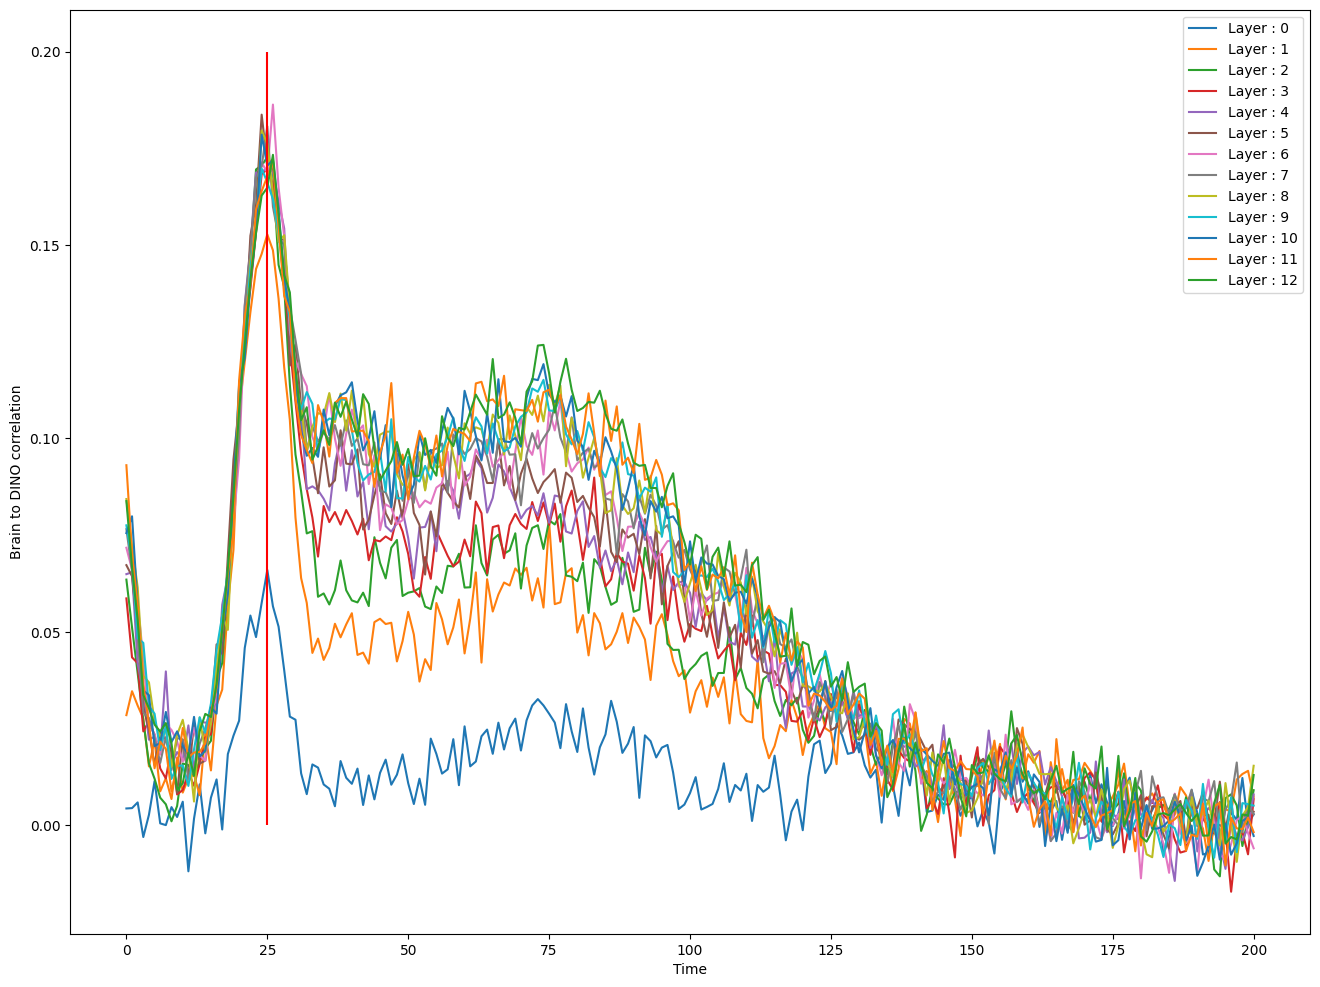

In [27]:
plt.figure(figsize = (16,12))
plt.xlabel("Time")
plt.ylabel("Brain to DINO correlation")
for i in range(len(correlations)):
    plt.plot(correlations[i], label = "Layer : "+ str(i))

plt.vlines(25, 0, 0.2, colors= "r")
plt.legend()
plt.show()

In [35]:
corr_array = np.array(correlations)
max_array = corr_array.max(1)
print(max_array.shape)


(13,)


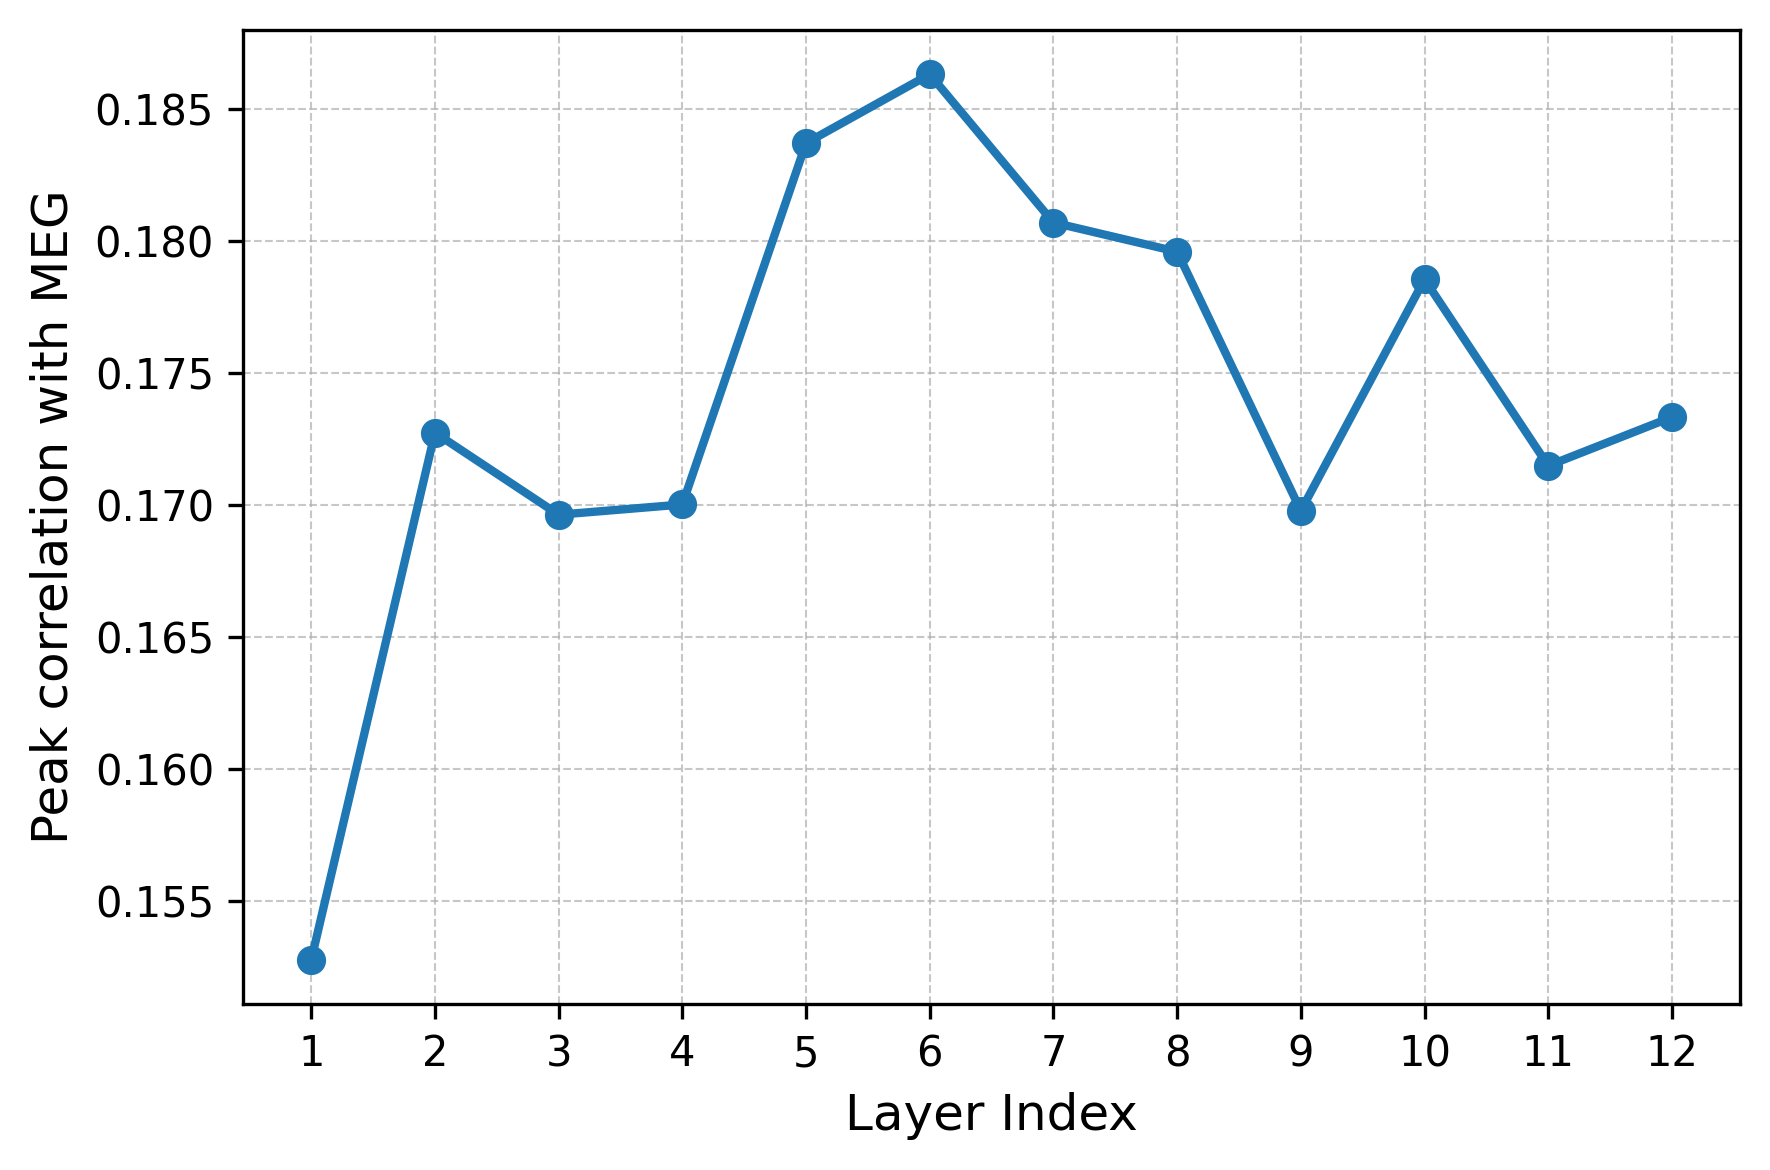

In [38]:
#Coded with ChatGPT

y = max_array[1:]
x = np.arange(1, len(y) + 1)  

plt.figure(figsize=(6, 4), dpi=300)

plt.plot(x, y, marker='o', linewidth=2)


plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Peak correlation with MEG", fontsize=12)

plt.xticks(x)
plt.tick_params(axis='both', which='major', labelsize=10)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

plt.show()

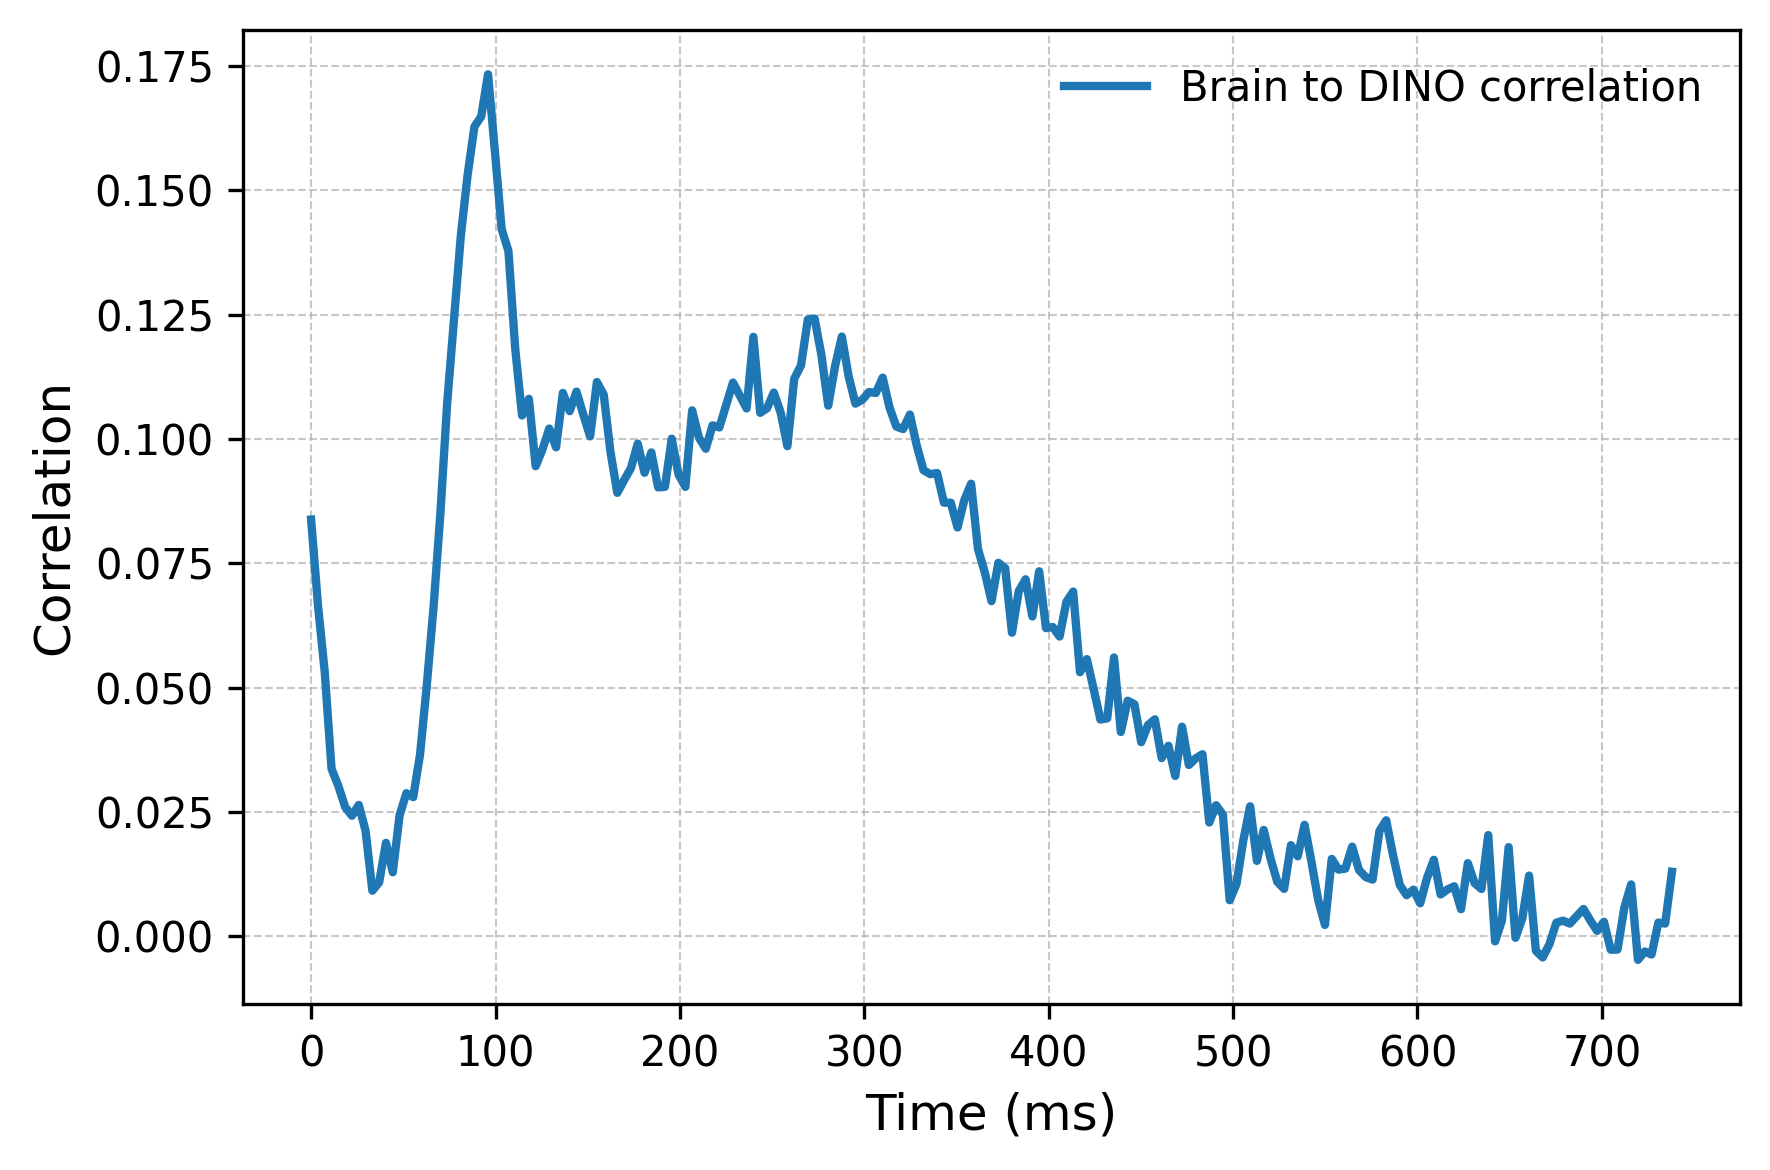

In [42]:
#Coded with the help of ChatGPT

y = correlations[-1]
x = (np.arange(len(y))/271)*1000

plt.figure(figsize=(6, 4), dpi=300)

plt.plot(x, y, linewidth=2, label="Brain to DINO correlation")

plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Correlation", fontsize=12)

plt.tick_params(axis='both', which='major', labelsize=10)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend(frameon=False, fontsize=10)

plt.tight_layout()

plt.show()

Computing energy...


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Plotting...


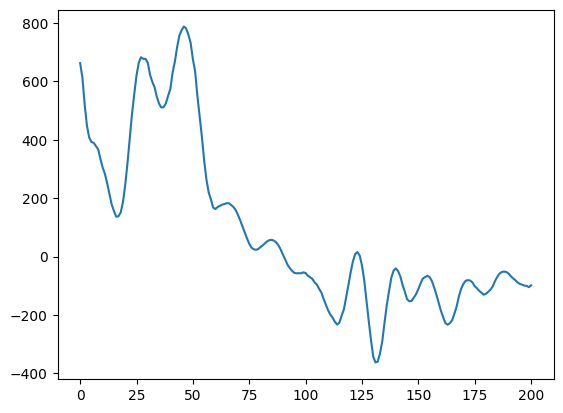

In [47]:
eeg_stack = np.mean(data["eeg"][0], axis = 1) / np.std(data["eeg"][0], axis = 1)

print("Computing energy...")
for i in range(1, len(data["eeg"])):

    eeg_stack  += np.mean(data["eeg"][i],  axis = 1) / np.std(data["eeg"][i],  axis = 1)

print("Plotting...")

plt.plot(eeg_stack.squeeze())
plt.show()

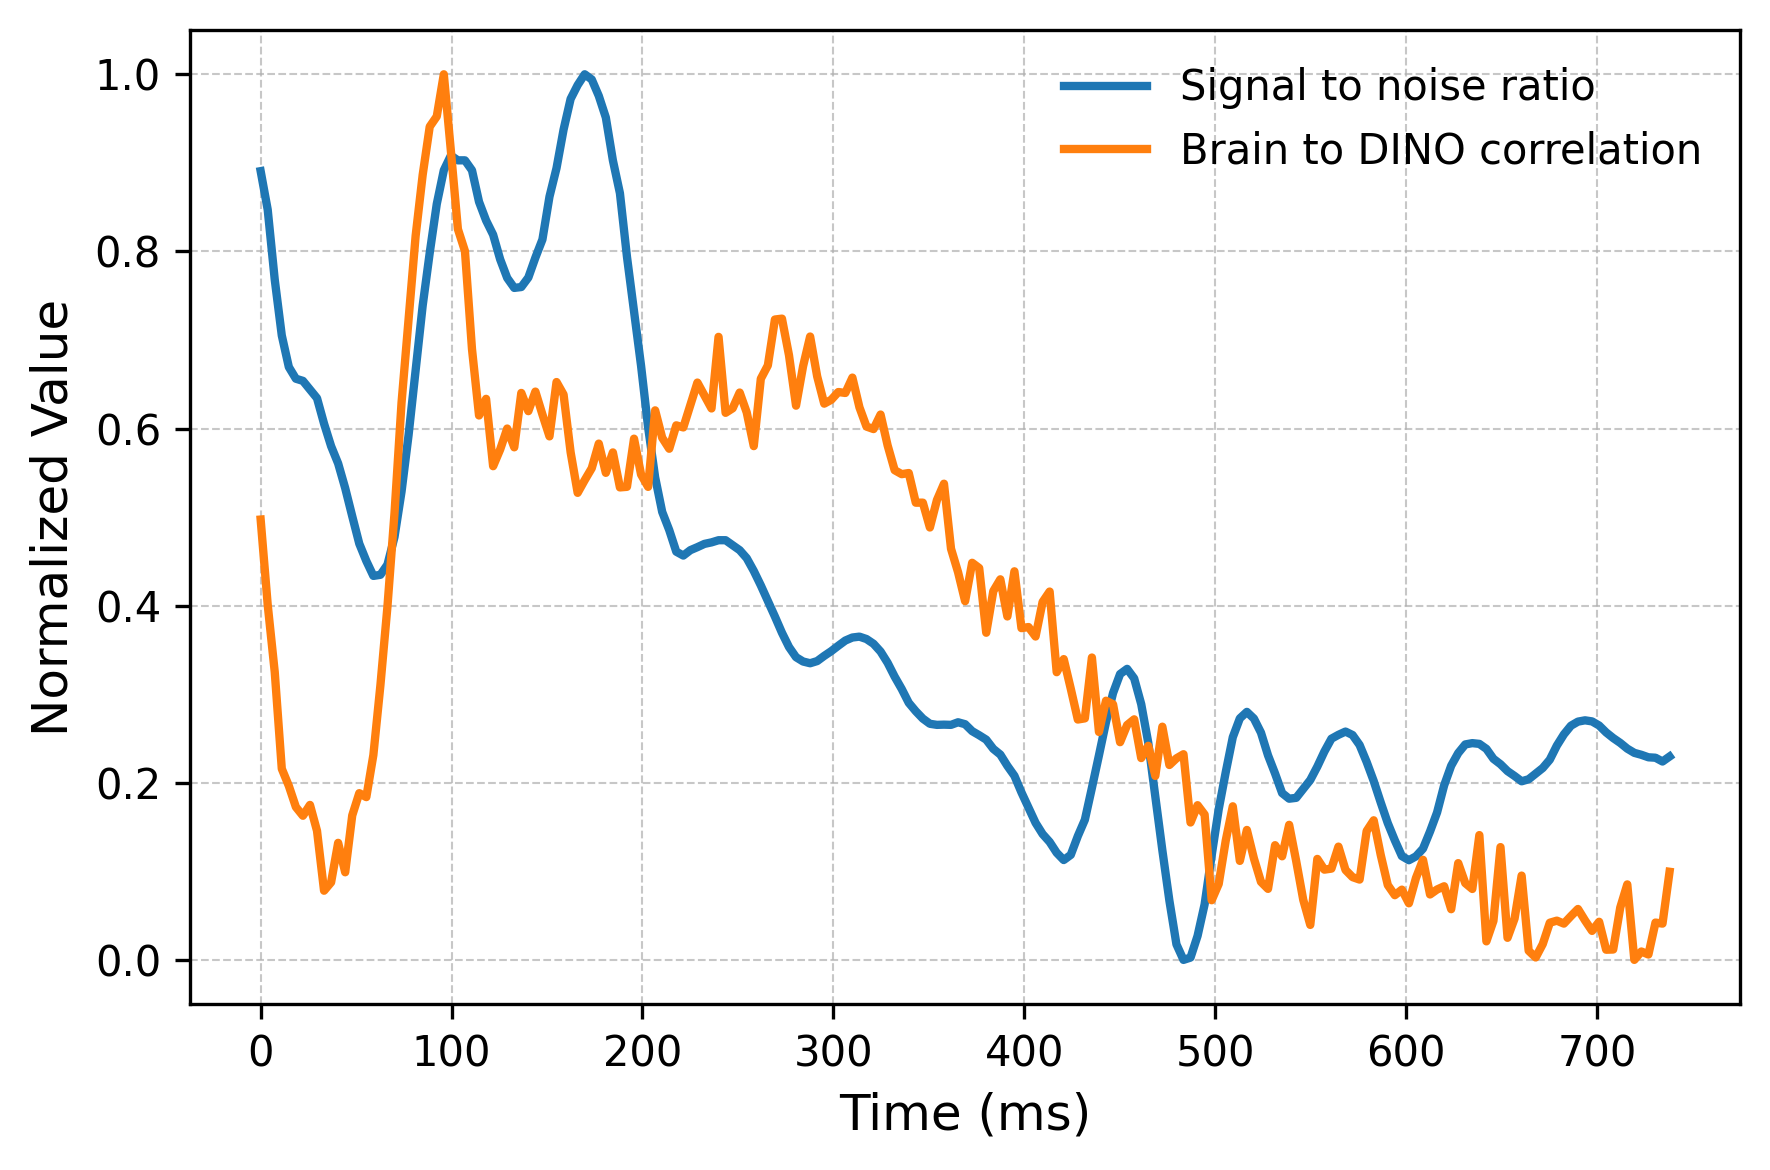

In [55]:
#Coded with the help of ChatGPT

eeg = eeg_stack.squeeze()
corr = correlations[-1]


eeg_z = (eeg - np.min(eeg)) / (np.max(eeg) - np.min(eeg)) 
corr_z = (corr - np.min(corr)) / (np.max(corr) - np.min(corr)) 

t = (np.arange(len(corr_z))/271)*1000

plt.figure(figsize=(6, 4), dpi=300)

plt.plot(t, eeg_z, linewidth=2, label="Signal to noise ratio")
plt.plot(t, corr_z, linewidth=2, label="Brain to DINO correlation")

plt.xlabel("Time (ms)", fontsize=12)
plt.ylabel("Normalized Value", fontsize=12)

plt.tick_params(axis='both', labelsize=10)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.legend(frameon=False, fontsize=10)

plt.tight_layout()

plt.show()

In [51]:
print(np.corrcoef(correlations[-1], eeg_stack.squeeze()))

[[1.         0.61280773]
 [0.61280773 1.        ]]
